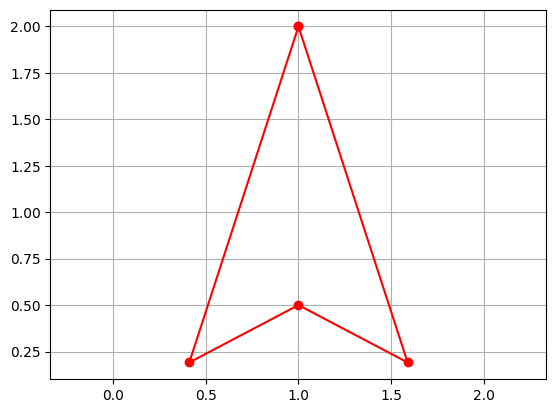

In [16]:
import numpy as np
import matplotlib.pyplot as plt

angles = np.deg2rad([90, 234, 306, 90])
r = 1

x = r * np.cos(angles)
y = r * np.sin(angles)

# print(x, y)

points = np.column_stack((x, y))

extra_point = [0, -0.5]

points = np.vstack((points, extra_point))
points = points[[0, 1, 4, 2, 3]] + [1, 1]

fig, ax = plt.subplots()
ax.plot(points[:, 0], points[:, 1], 'r-o')



plt.grid(True)
plt.axis('equal')
plt.show()

True
True


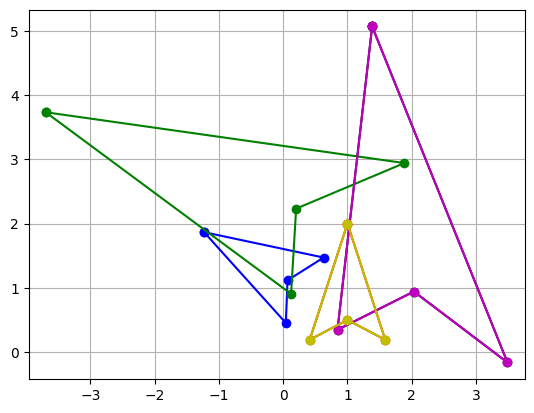

U
 [[ 0.5        0.8660254]
 [-0.8660254  0.5      ]]
sigma
 [[3 0]
 [0 2]]
Vt
 [[ 0.5       -0.8660254]
 [ 0.8660254  0.5      ]]


In [41]:
angle = np.deg2rad(60)

fig, ax = plt.subplots()
ax.plot(points[:, 0], points[:, 1], 'r-o')


Vt = np.array([
    [np.cos(angle), -np.sin(angle)],
    [np.sin(angle), np.cos(angle)]
])

step1 = (Vt @ points.T).T
ax.plot(step1[:, 0], step1[:, 1], 'b-o')

sigma = np.diag([3, 2])
step2 = (sigma @ step1.T).T
ax.plot(step2[:, 0], step2[:, 1], 'g-o')

angle2 = -angle
U = np.array([
    [np.cos(angle2), -np.sin(angle2)],
    [np.sin(angle2), np.cos(angle2)]
])

step3 = (U @ step2.T).T
ax.plot(step3[:, 0], step3[:, 1], 'k-o')

step4 = (U @ sigma @ Vt @ points.T).T
ax.plot(step3[:, 0], step3[:, 1], 'm-o')

print(np.allclose(step4, step4))


step5 = (np.linalg.inv(U @ sigma @ Vt) @ step4.T).T
ax.plot(step5[:, 0], step5[:, 1], 'y-o')

print(np.allclose(points, step5))

transformM = U @ sigma @ Vt

plt.grid(True)
plt.axis('equal')
plt.show()

print('U\n', U)
print('sigma\n', sigma)
print('Vt\n', Vt)


[[3. 0.]
 [0. 2.]]
True


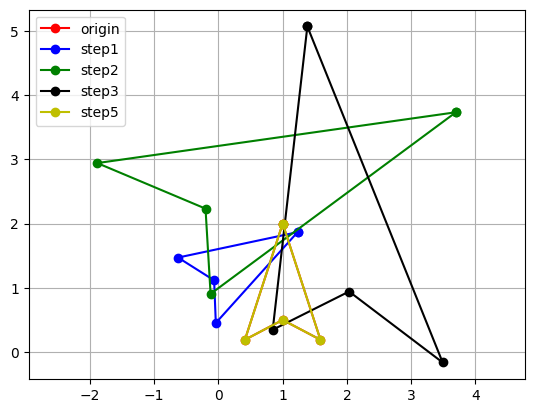

U
 [[-0.5        0.8660254]
 [ 0.8660254  0.5      ]]
sigma
 [[3. 0.]
 [0. 2.]]
Vt
 [[-0.5        0.8660254]
 [ 0.8660254  0.5      ]]


In [42]:

U, s, Vt = np.linalg.svd(transformM)

fig, ax = plt.subplots()
ax.plot(points[:, 0], points[:, 1], 'r-o', label='origin')

# print(Vt)

# alpha = np.deg2rad(60*2)
# print(np.array([
#     [np.cos(alpha), np.sin(alpha)],
#     [np.sin(alpha), -np.cos(alpha)]
# ]))


step1 = (Vt @ points.T).T
ax.plot(step1[:, 0], step1[:, 1], 'b-o', label='step1')

sigma = np.diag(s)
print(sigma)

step2 = (sigma @ step1.T).T
ax.plot(step2[:, 0], step2[:, 1], 'g-o', label='step2')

step3 = (U @ step2.T).T
ax.plot(step3[:, 0], step3[:, 1], 'k-o', label='step3')


step5 = (np.linalg.inv(transformM) @ step3.T).T
ax.plot(step5[:, 0], step5[:, 1], 'y-o', label='step5')

print(np.allclose(points, step5))

plt.grid(True)
plt.axis('equal')
plt.legend()
plt.show()


print('U\n', U)
print('sigma\n', sigma)
print('Vt\n', Vt)